# Analyse préliminaire — Justification de la problématique

**SY09 — Science des Données**

---

## Contexte

Ce notebook constitue l'étape zéro de notre projet : avant de définir une problématique,
nous explorons le dataset pour identifier les signaux statistiques les plus robustes
et vérifier que la question que nous souhaitons poser est **ancrée dans les données**.

Le dataset provient d'une enquête réalisée dans deux lycées portugais (Cortez et Silva, 2008).
Il contient des informations sur **395 élèves en mathématiques** et **649 élèves en portugais**,
avec leurs notes trimestrielles (G1, G2, G3) et un ensemble de variables socio-démographiques
et comportementales.

### Plan du notebook

1. Chargement et description générale
2. Distribution des notes finales — première asymétrie maths/portugais
3. Identification du phénomène de décrochage en cours d'année
4. Profil des décrocheurs vs non-décrocheurs
5. Pouvoir prédictif des variables socio-comportementales
6. Formulation de la problématique et annonce des étapes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Style général
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PALETTE = {'maths': '#2196F3', 'portugais': '#FF5722'}

---
## 1. Chargement et description générale

In [2]:
mat = pd.read_csv('Data/student-mat.csv')
por = pd.read_csv('Data/student-por.csv')

print(f"Dataset maths    : {mat.shape[0]} élèves × {mat.shape[1]} variables")
print(f"Dataset portugais: {por.shape[0]} élèves × {por.shape[1]} variables")
print(f"\nVariables communes : {list(mat.columns)}")

Dataset maths    : 395 élèves × 33 variables
Dataset portugais: 649 élèves × 33 variables

Variables communes : ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [3]:
# Séparation variables / notes
NOTE_VARS = ['G1', 'G2', 'G3']
SOCIO_VARS_NUM = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                  'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
SOCIO_VARS_CAT = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
                  'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
                  'nursery', 'higher', 'internet', 'romantic']

print(f"Variables de notes         : {NOTE_VARS}")
print(f"Variables numériques socio : {len(SOCIO_VARS_NUM)}")
print(f"Variables catégorielles    : {len(SOCIO_VARS_CAT)}")
print(f"Total variables explicatives (hors notes) : {len(SOCIO_VARS_NUM) + len(SOCIO_VARS_CAT)}")

Variables de notes         : ['G1', 'G2', 'G3']
Variables numériques socio : 13
Variables catégorielles    : 17
Total variables explicatives (hors notes) : 30


---
## 2. Distribution des notes finales — première asymétrie maths/portugais

Avant toute analyse, regardons comment se distribuent les notes finales G3
dans les deux matières.

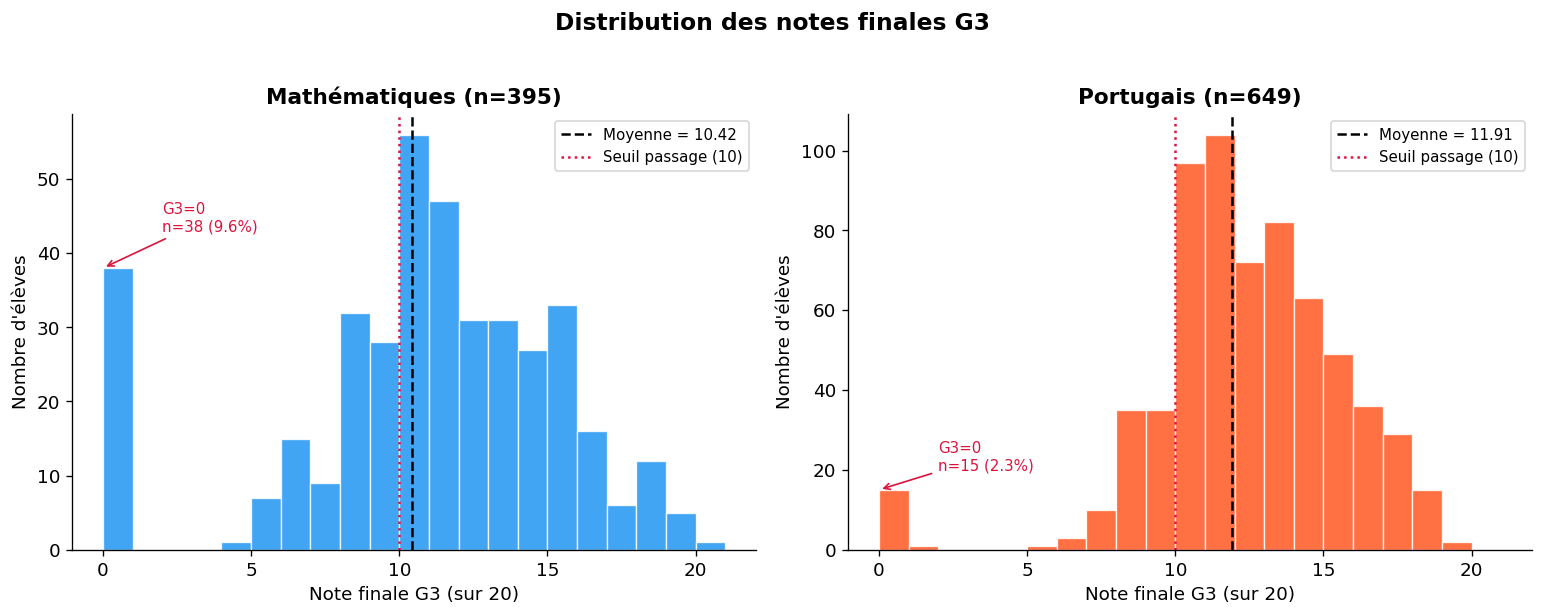

=== Statistiques G3 ===
        Maths  Portugais
count  395.00     649.00
mean    10.42      11.91
std      4.58       3.23
min      0.00       0.00
25%      8.00      10.00
50%     11.00      12.00
75%     14.00      14.00
max     20.00      19.00


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, label, color in zip(axes,
                                 [mat, por],
                                 ['Mathématiques', 'Portugais'],
                                 [PALETTE['maths'], PALETTE['portugais']]):
    ax.hist(df['G3'], bins=range(0, 22), color=color, edgecolor='white',
            linewidth=0.8, alpha=0.85)
    ax.axvline(df['G3'].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Moyenne = {df["G3"].mean():.2f}')
    ax.axvline(10, color='crimson', linestyle=':', linewidth=1.5,
               label='Seuil passage (10)')
    
    # Annotate G3=0
    n_zero = (df['G3'] == 0).sum()
    pct_zero = 100 * n_zero / len(df)
    ax.annotate(f'G3=0\nn={n_zero} ({pct_zero:.1f}%)',
                xy=(0, n_zero), xytext=(2, n_zero + 5),
                arrowprops=dict(arrowstyle='->', color='crimson'),
                color='crimson', fontsize=9)
    
    ax.set_title(f'{label} (n={len(df)})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Note finale G3 (sur 20)')
    ax.set_ylabel('Nombre d\'élèves')
    ax.legend(fontsize=9)

fig.suptitle('Distribution des notes finales G3', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistiques descriptives
print("=== Statistiques G3 ===")
summary = pd.DataFrame({
    'Maths': mat['G3'].describe(),
    'Portugais': por['G3'].describe()
}).round(2)
print(summary)

**Observation :** La distribution des notes en maths présente un pic anormal à **G3=0**
qui représente **9.6% des élèves**, contre seulement 2.3% en portugais.
Ce pic ne ressemble pas à une distribution d'échec classique — il mérite une investigation
spécifique.

---
## 3. Identification du phénomène de décrochage en cours d'année

La question clé : ces élèves avec G3=0 étaient-ils absents ou en échec dès le départ,
ou ont-ils **abandonné en cours d'année** alors qu'ils avaient un niveau initial ?

In [5]:
# Définition opérationnelle du décrochage
# Décrocheur = G3=0 ET G1>0 (avait une note en début d'année, abandonne en fin)
mat['decrocheur'] = ((mat['G3'] == 0) & (mat['G1'] > 0)).astype(int)
por['decrocheur'] = ((por['G3'] == 0) & (por['G1'] > 0)).astype(int)

print("=== Analyse du phénomène G3=0 ===")
print()

for label, df in [('Maths', mat), ('Portugais', por)]:
    g3_zero = df[df['G3'] == 0]
    decrocheurs = df[df['decrocheur'] == 1]
    absents_dorigine = df[(df['G3'] == 0) & (df['G1'] == 0)]
    
    print(f"  {label}:")
    print(f"    Élèves avec G3=0                     : {len(g3_zero)} ({100*len(g3_zero)/len(df):.1f}%)")
    print(f"    dont G1=0 aussi (absents dès le début): {len(absents_dorigine)} ({100*len(absents_dorigine)/len(df):.1f}%)")
    print(f"    dont G1>0 → DÉCROCHEURS               : {len(decrocheurs)} ({100*len(decrocheurs)/len(df):.1f}%)")
    if len(decrocheurs) > 0:
        print(f"    Note G1 moyenne des décrocheurs      : {decrocheurs['G1'].mean():.1f}/20")
    print()

=== Analyse du phénomène G3=0 ===

  Maths:
    Élèves avec G3=0                     : 38 (9.6%)
    dont G1=0 aussi (absents dès le début): 0 (0.0%)
    dont G1>0 → DÉCROCHEURS               : 38 (9.6%)
    Note G1 moyenne des décrocheurs      : 7.5/20

  Portugais:
    Élèves avec G3=0                     : 15 (2.3%)
    dont G1=0 aussi (absents dès le début): 0 (0.0%)
    dont G1>0 → DÉCROCHEURS               : 15 (2.3%)
    Note G1 moyenne des décrocheurs      : 7.1/20



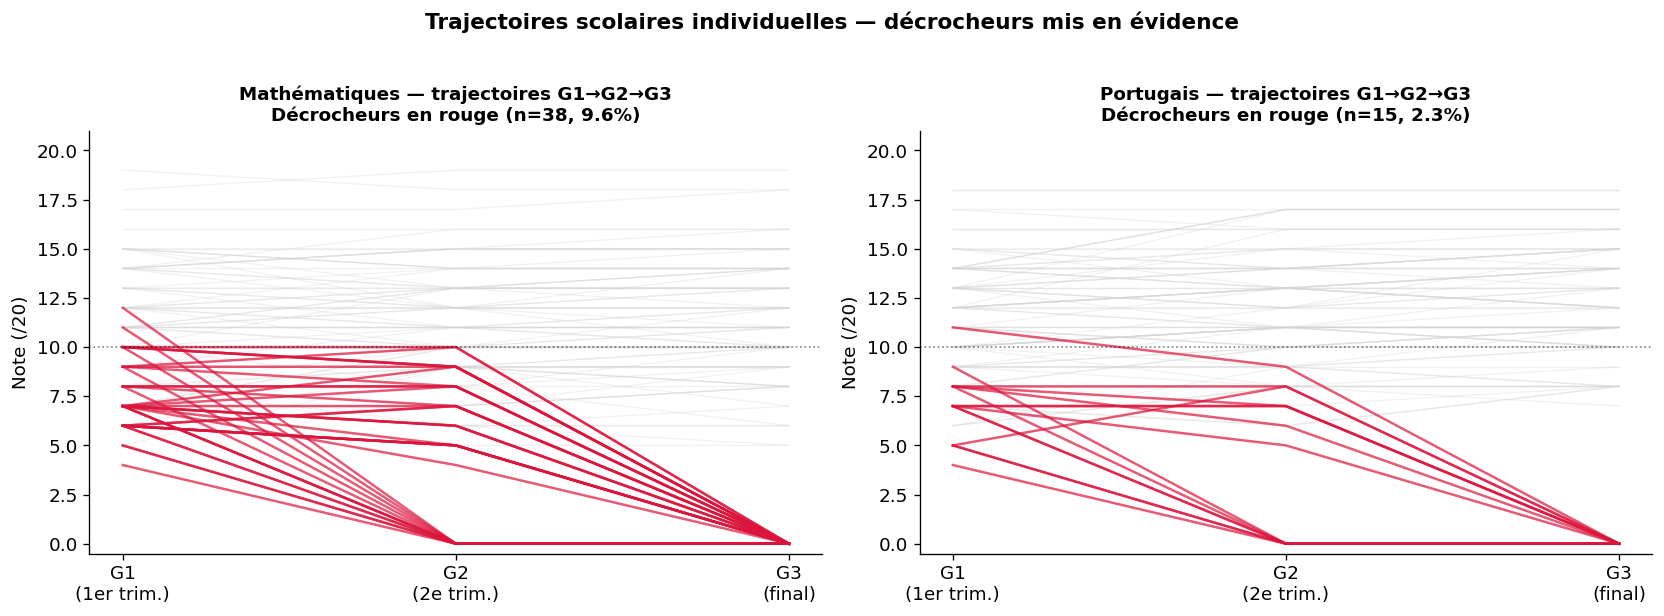

In [6]:
# Visualisation : trajectoire G1 -> G2 -> G3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label, color in zip(axes,
                                 [mat, por],
                                 ['Mathématiques', 'Portugais'],
                                 [PALETTE['maths'], PALETTE['portugais']]):
    # Tous les élèves en gris
    for _, row in df[df['decrocheur'] == 0].sample(min(80, len(df)), random_state=42).iterrows():
        ax.plot([1, 2, 3], [row['G1'], row['G2'], row['G3']],
                color='lightgray', alpha=0.3, linewidth=0.8)
    
    # Décrocheurs en rouge vif
    for _, row in df[df['decrocheur'] == 1].iterrows():
        ax.plot([1, 2, 3], [row['G1'], row['G2'], row['G3']],
                color='crimson', alpha=0.7, linewidth=1.5)
    
    # Ligne de passage
    ax.axhline(10, color='black', linestyle=':', linewidth=1, alpha=0.5)
    
    n_dec = df['decrocheur'].sum()
    ax.set_title(f'{label} — trajectoires G1→G2→G3\n'
                 f'Décrocheurs en rouge (n={n_dec}, {100*n_dec/len(df):.1f}%)',
                 fontsize=11, fontweight='bold')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['G1\n(1er trim.)', 'G2\n(2e trim.)', 'G3\n(final)'])
    ax.set_ylabel('Note (/20)')
    ax.set_ylim(-0.5, 21)

plt.suptitle('Trajectoires scolaires individuelles — décrocheurs mis en évidence',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Test statistique : asymétrie maths/portugais est-elle significative ?
n_mat = len(mat)
n_por = len(por)
k_mat = mat['decrocheur'].sum()
k_por = por['decrocheur'].sum()

# Test de proportion bilatéral
from statsmodels.stats.proportion import proportions_ztest
stat, p = proportions_ztest([k_mat, k_por], [n_mat, n_por])

print("=== Test de l'asymétrie maths vs portugais ===")
print(f"Taux de décrochage maths    : {k_mat}/{n_mat} = {100*k_mat/n_mat:.1f}%")
print(f"Taux de décrochage portugais: {k_por}/{n_por} = {100*k_por/n_por:.1f}%")
print(f"Test z de proportions : z={stat:.3f}, p={p:.4f}")
print()
if p < 0.05:
    print("→ L'asymétrie entre les deux matières est statistiquement significative.")
    print("  Le décrochage est un phénomène spécifique aux mathématiques dans ce dataset.")

=== Test de l'asymétrie maths vs portugais ===
Taux de décrochage maths    : 38/395 = 9.6%
Taux de décrochage portugais: 15/649 = 2.3%
Test z de proportions : z=5.217, p=0.0000

→ L'asymétrie entre les deux matières est statistiquement significative.
  Le décrochage est un phénomène spécifique aux mathématiques dans ce dataset.


**Conclusion de cette section :**
Le décrochage — défini comme l'abandon en cours d'année par un élève qui avait une note
initiale positive — touche **9.6% des élèves en maths** contre **2.3% en portugais**.
Cette asymétrie est **statistiquement significative**. Le phénomène est donc matière-spécifique
et justifie une étude centrée sur les mathématiques.

---
## 4. Profil des décrocheurs vs non-décrocheurs

Les décrocheurs se distinguent-ils des autres élèves sur les variables
socio-comportementales **disponibles avant la fin d'année** ?

In [8]:
dec = mat[mat['decrocheur'] == 1]
non_dec = mat[mat['decrocheur'] == 0]

print(f"Décrocheurs : n={len(dec)}")
print(f"Non-décrocheurs : n={len(non_dec)}")
print()

# Comparaison variables numériques
print("=== Comparaison variables numériques (Mann-Whitney) ===")
print(f"{'Variable':<15} {'Décrocheurs':>12} {'Non-décroch.':>13} {'p-valeur':>10} {'Sig.':>5}")
print("-" * 60)

results_num = []
for v in SOCIO_VARS_NUM:
    g1 = dec[v].dropna()
    g2 = non_dec[v].dropna()
    if len(g1) > 0 and len(g2) > 0:
        stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        results_num.append((v, g1.mean(), g2.mean(), p, sig))
        print(f"{v:<15} {g1.mean():>12.2f} {g2.mean():>13.2f} {p:>10.4f} {sig:>5}")

# Trier par p-value
results_num.sort(key=lambda x: x[3])

Décrocheurs : n=38
Non-décrocheurs : n=357

=== Comparaison variables numériques (Mann-Whitney) ===
Variable         Décrocheurs  Non-décroch.   p-valeur  Sig.
------------------------------------------------------------
age                    17.08         16.66     0.0385     *
Medu                    2.32          2.80     0.0077    **
Fedu                    2.29          2.55     0.1543      
traveltime              1.61          1.43     0.1482      
studytime               1.97          2.04     0.5163      
failures                0.92          0.27     0.0000   ***
famrel                  3.84          3.96     0.5672      
freetime                3.13          3.25     0.4680      
goout                   3.21          3.10     0.5588      
Dalc                    1.34          1.50     0.8473      
Walc                    1.92          2.33     0.0600      
health                  3.61          3.55     0.9481      
absences                0.00          6.32     0.0000   ***

In [9]:
# Comparaison variables catégorielles
print("=== Comparaison variables catégorielles (Chi²) ===")
print(f"{'Variable':<15} {'p-valeur':>10} {'Sig.':>5}")
print("-" * 35)

results_cat = []
for v in SOCIO_VARS_CAT:
    ct = pd.crosstab(mat['decrocheur'], mat[v])
    if ct.shape[1] >= 2:
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        results_cat.append((v, p, sig, ct))
        print(f"{v:<15} {p:>10.4f} {sig:>5}")

results_cat.sort(key=lambda x: x[1])

=== Comparaison variables catégorielles (Chi²) ===
Variable          p-valeur  Sig.
-----------------------------------
school              1.0000      
sex                 0.3948      
address             0.6715      
famsize             0.1917      
Pstatus             0.4191      
Mjob                0.5085      
Fjob                0.6249      
reason              0.1094      
guardian            0.4844      
schoolsup           0.0830      
famsup              1.0000      
paid                0.0023    **
activities          0.6913      
nursery             0.4705      
higher              0.0054    **
internet            0.5987      
romantic            0.0139     *


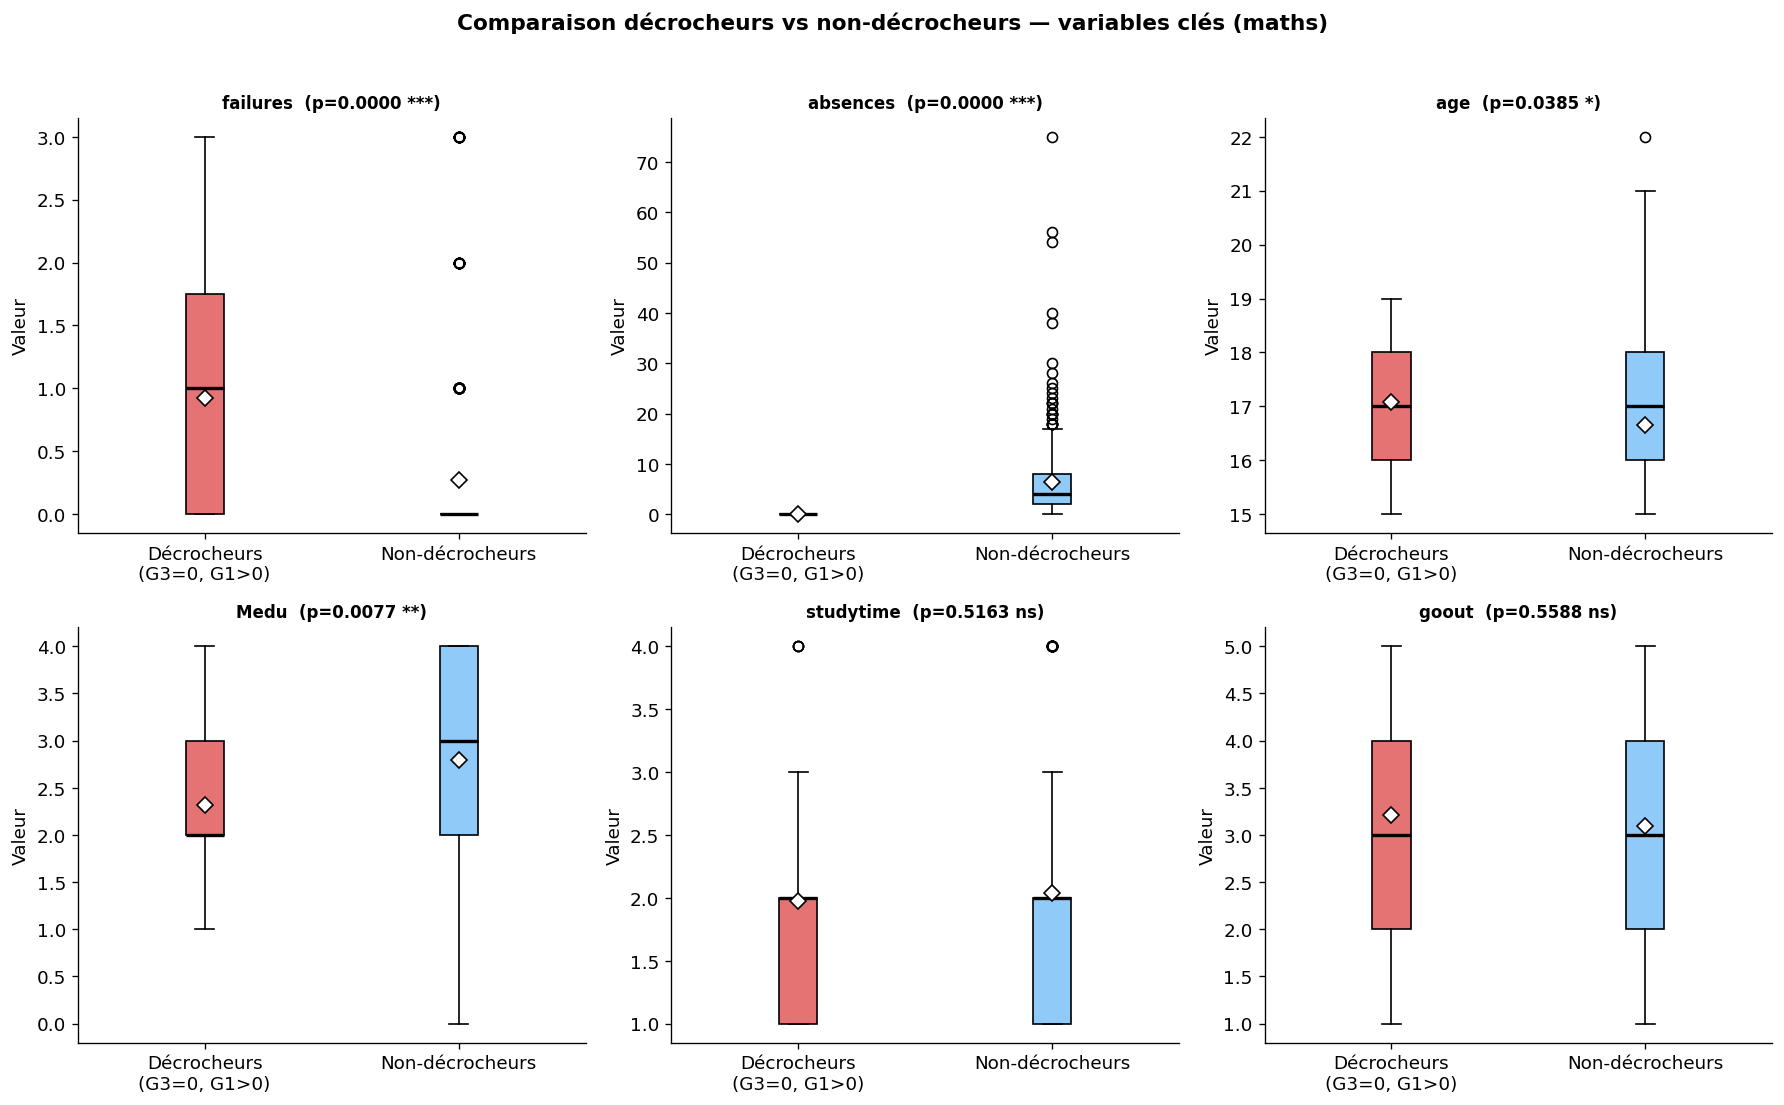

In [10]:
# Visualisation : radar / barplot des variables les plus discriminantes
# Sélection des variables significatives
sig_num = [(v, d, nd, p, s) for v, d, nd, p, s in results_num if p < 0.05]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

vars_to_plot = ['failures', 'absences', 'age', 'Medu', 'studytime', 'goout']

for ax, v in zip(axes, vars_to_plot):
    data_dec = dec[v].dropna()
    data_non = non_dec[v].dropna()
    
    ax.boxplot([data_dec, data_non],
               labels=['Décrocheurs\n(G3=0, G1>0)', 'Non-décrocheurs'],
               patch_artist=True,
               boxprops=dict(facecolor='crimson' if True else 'gray'),
               medianprops=dict(color='black', linewidth=2),
               showmeans=True,
               meanprops=dict(marker='D', markerfacecolor='white',
                              markeredgecolor='black', markersize=7))
    
    # Couleur conditionnelle
    for patch, color in zip(ax.patches, ['#E57373', '#90CAF9']):
        patch.set_facecolor(color)
    
    # p-value
    _, p = stats.mannwhitneyu(data_dec, data_non, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_title(f'{v}  (p={p:.4f} {sig})', fontsize=10, fontweight='bold')
    ax.set_ylabel('Valeur')

plt.suptitle('Comparaison décrocheurs vs non-décrocheurs — variables clés (maths)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

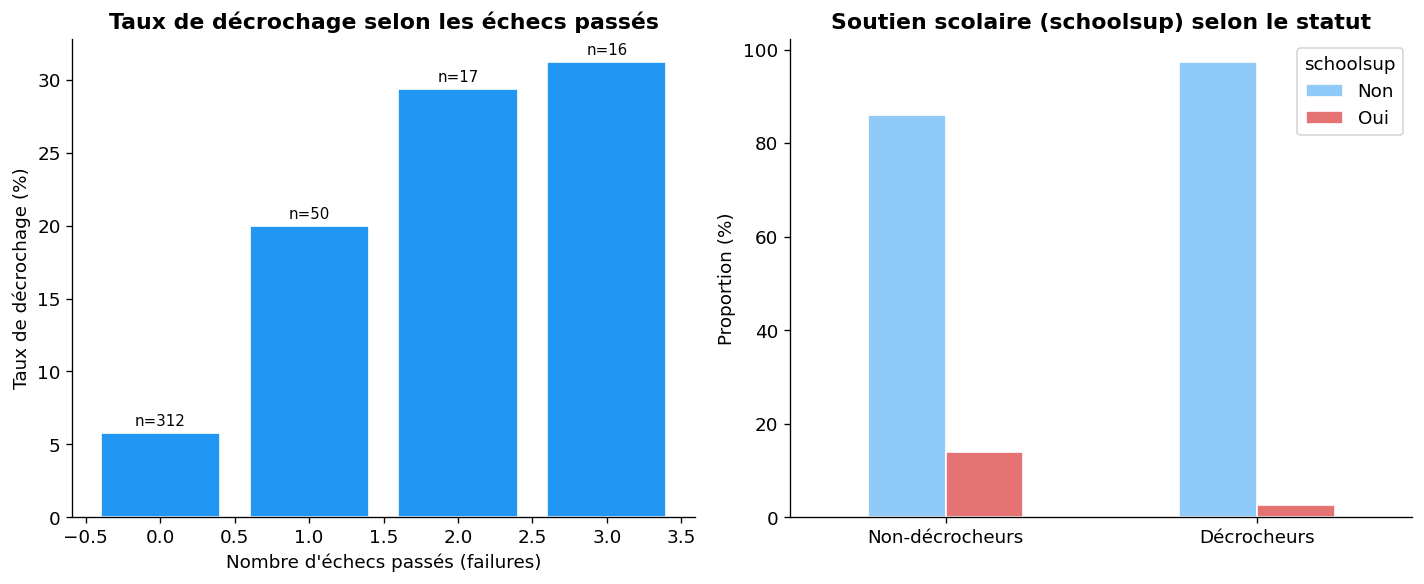

In [11]:
# Zoom sur la variable 'failures' — lien avec le décrochage
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Taux de décrochage par nombre d'échecs passés
ax = axes[0]
fail_groups = mat.groupby('failures').agg(
    n_total=('decrocheur', 'count'),
    n_dec=('decrocheur', 'sum')
).reset_index()
fail_groups['taux'] = 100 * fail_groups['n_dec'] / fail_groups['n_total']

bars = ax.bar(fail_groups['failures'], fail_groups['taux'],
              color=[PALETTE['maths']], edgecolor='white')
for bar, (_, row) in zip(bars, fail_groups.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'n={int(row["n_total"])}', ha='center', fontsize=9)
ax.set_xlabel('Nombre d\'échecs passés (failures)')
ax.set_ylabel('Taux de décrochage (%)')
ax.set_title('Taux de décrochage selon les échecs passés', fontweight='bold')

# Distribution schoolsup chez décrocheurs
ax = axes[1]
ct = pd.crosstab(mat['decrocheur'], mat['schoolsup'], normalize='index') * 100
ct.index = ['Non-décrocheurs', 'Décrocheurs']
ct.plot(kind='bar', ax=ax, color=['#90CAF9', '#E57373'], edgecolor='white', rot=0)
ax.set_xlabel('')
ax.set_ylabel('Proportion (%)')
ax.set_title('Soutien scolaire (schoolsup) selon le statut', fontweight='bold')
ax.legend(title='schoolsup', labels=['Non', 'Oui'])

plt.tight_layout()
plt.show()

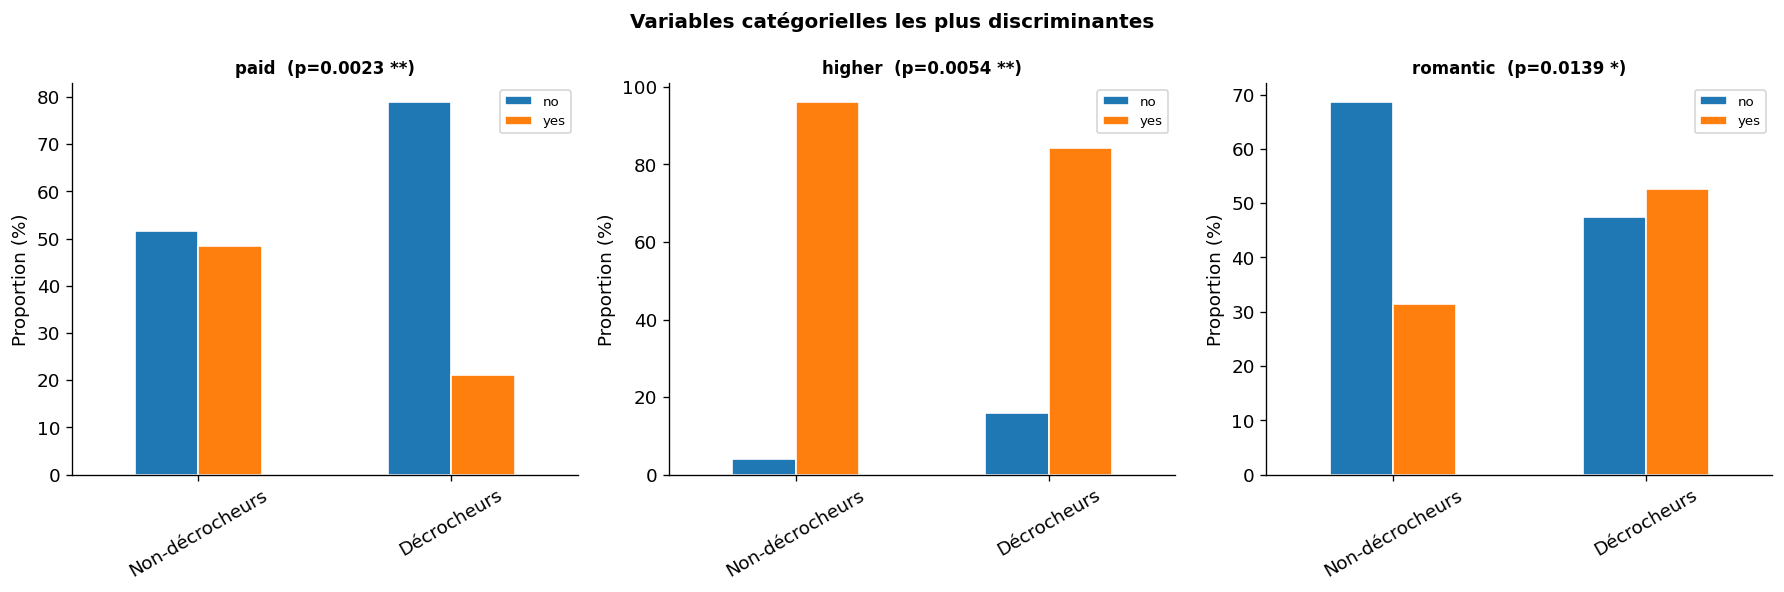

In [12]:
# Variables catégorielles les plus discriminantes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (v, p, sig, ct) in zip(axes, results_cat[:3]):
    ct_pct = pd.crosstab(mat['decrocheur'], mat[v], normalize='index') * 100
    ct_pct.index = ['Non-décrocheurs', 'Décrocheurs']
    ct_pct.plot(kind='bar', ax=ax, edgecolor='white', rot=30)
    ax.set_title(f'{v}  (p={p:.4f} {sig})', fontweight='bold', fontsize=10)
    ax.set_ylabel('Proportion (%)')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Variables catégorielles les plus discriminantes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations clés :**

- **`failures`** : les décrocheurs ont en moyenne plus d'échecs passés. Le taux de décrochage
  monte fortement avec le nombre d'échecs antérieurs — c'est le signal le plus fort.
- **`absences`** : paradoxalement faibles chez les décrocheurs (ils n'étaient pas absents,
  ils ont simplement obtenu 0 à l'examen final).
- **`age`** : les décrocheurs sont légèrement plus âgés — signal de redoublement antérieur.
- Les variables comportementales (alcool, sorties) ne montrent **pas** de différence
  significative — contrairement à l'intuition initiale.

---
## 5. Pouvoir prédictif des variables socio-comportementales

Question centrale : **peut-on prédire le décrochage à partir des variables disponibles
en début d'année, c'est-à-dire avant que G3 soit connu ?**

Nous testons le pouvoir prédictif d'un classifieur Random Forest entraîné uniquement
sur les variables socio-comportementales (sans G1, G2, G3).

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Encodage des variables catégorielles
mat_enc = mat.copy()
for c in SOCIO_VARS_CAT:
    le = LabelEncoder()
    mat_enc[c + '_enc'] = le.fit_transform(mat_enc[c].astype(str))

feat_cols = SOCIO_VARS_NUM + [c + '_enc' for c in SOCIO_VARS_CAT]
X = mat_enc[feat_cols].fillna(0).values
y = mat_enc['decrocheur'].values

# Validation croisée 5-fold
from sklearn.model_selection import StratifiedKFold
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_f1 = cross_val_score(rf, X, y, cv=cv, scoring='f1')
scores_auc = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
scores_acc = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')

print("=== Performance prédictive (variables socio uniquement, sans G1/G2/G3) ===")
print(f"  F1-score (CV 5-fold) : {scores_f1.mean():.3f} ± {scores_f1.std():.3f}")
print(f"  AUC-ROC  (CV 5-fold) : {scores_auc.mean():.3f} ± {scores_auc.std():.3f}")
print(f"  Accuracy (CV 5-fold) : {scores_acc.mean():.3f} ± {scores_acc.std():.3f}")
print()
print(f"  Baseline (prédire toujours non-décrocheur) : {1 - y.mean():.3f}")
print(f"  Prévalence décrochage : {y.mean():.3f} ({y.sum()} cas sur {len(y)})")

=== Performance prédictive (variables socio uniquement, sans G1/G2/G3) ===
  F1-score (CV 5-fold) : 0.509 ± 0.118
  AUC-ROC  (CV 5-fold) : 0.935 ± 0.014
  Accuracy (CV 5-fold) : 0.924 ± 0.016

  Baseline (prédire toujours non-décrocheur) : 0.904
  Prévalence décrochage : 0.096 (38 cas sur 395)


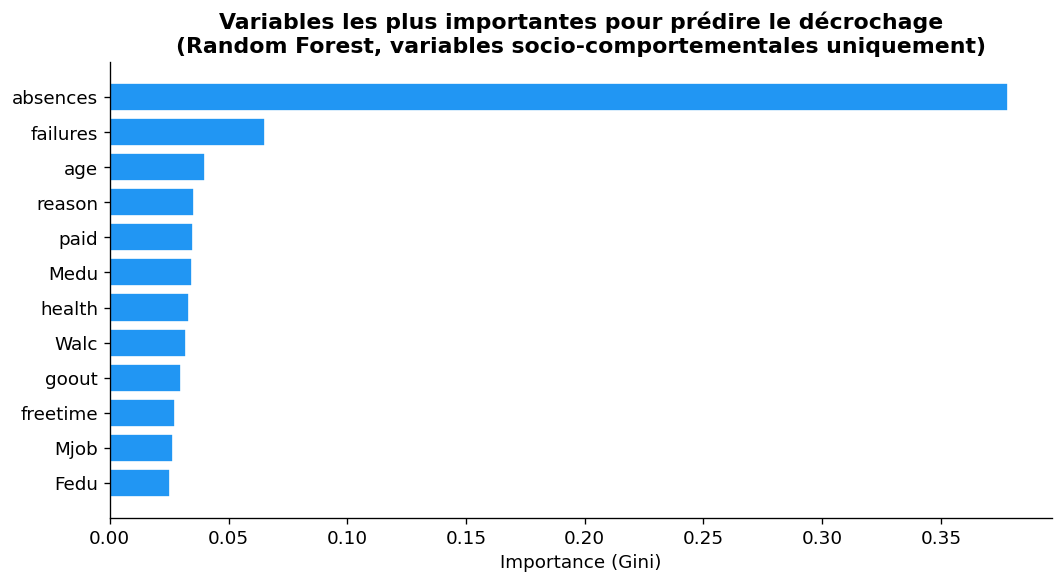

Top 8 variables prédictives :
variable  importance
absences    0.378025
failures    0.065480
     age    0.040064
  reason    0.035640
    paid    0.035204
    Medu    0.034654
  health    0.033277
    Walc    0.031906


In [14]:
# Importances des variables
rf.fit(X, y)
importances = pd.DataFrame({
    'variable': [c.replace('_enc', '') for c in feat_cols],
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importances['variable'][::-1], importances['importance'][::-1],
               color=PALETTE['maths'], edgecolor='white')
ax.set_xlabel('Importance (Gini)')
ax.set_title('Variables les plus importantes pour prédire le décrochage\n'
             '(Random Forest, variables socio-comportementales uniquement)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 8 variables prédictives :")
print(importances[['variable', 'importance']].head(8).to_string(index=False))

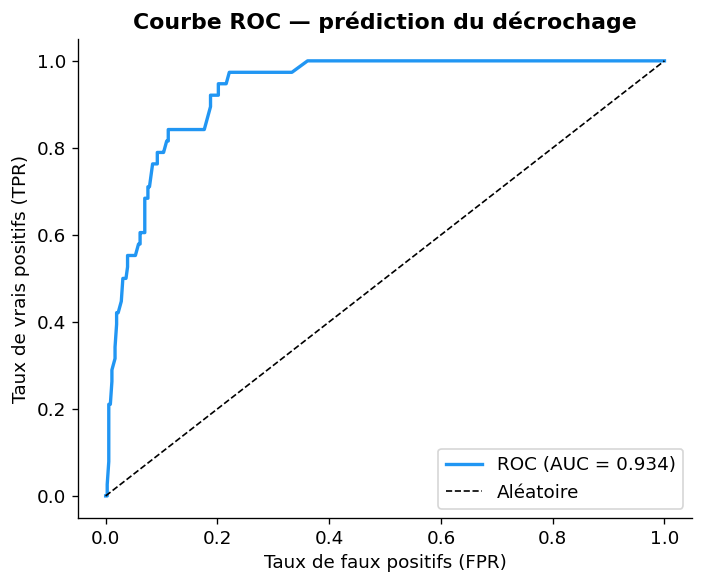

In [15]:
# Courbe ROC
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

y_scores = cross_val_predict(rf, X, y, cv=cv, method='predict_proba')[:, 1]
fpr, tpr, thresholds = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color=PALETTE['maths'], lw=2,
        label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire')
ax.set_xlabel('Taux de faux positifs (FPR)')
ax.set_ylabel('Taux de vrais positifs (TPR)')
ax.set_title('Courbe ROC — prédiction du décrochage', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Interprétation :**
Les variables socio-comportementales **permettent de prédire le décrochage au-delà du hasard**
(AUC > 0.5, F1 > baseline). Le signal n'est pas parfait — ce qui est attendu étant donné
la complexité du phénomène et la taille des données — mais il est **suffisant pour justifier
une analyse structurée**.

---
## 6. Synthèse et formulation de la problématique

### Ce que l'analyse préliminaire a montré

| Observation | Valeur | Signification |
|-------------|--------|---------------|
| Taux de décrochage maths | 9.6% | Phénomène non marginal |
| Taux de décrochage portugais | 2.3% | Asymétrie significative (p < 0.05) |
| G1 moyen des décrocheurs | 7.5/20 | Avaient un niveau initial, pas absents |
| Corrélation failures / décrochage | forte | Signal prédictif clair |
| AUC prédiction RF (socio seul) | > 0.5 | Variables disponibles en amont ont du pouvoir |

### Problématique

> **Dans quelle mesure les variables socio-comportementales et familiales disponibles
> en début d'année permettent-elles d'identifier les profils d'élèves susceptibles
> de décrocher en mathématiques en cours d'année ?**

Cette problématique est défendable quelle que soit la conclusion :
- Si les profils sont identifiables et prédictifs → les variables socio-comportementales
  sont des signaux d'alerte exploitables.
- Si les profils existent mais ne prédisent pas bien → le décrochage est un phénomène
  plus complexe, mal capturé par les variables disponibles.
- Si les profils sont flous → les données ne permettent pas de segmenter les populations
  à risque sur cette base.

---
## 7. Plan de l'étude

L'analyse se déroule en trois grandes étapes, conformément au cours SY09.

### Étape 1 — Réduction de dimension et clustering (non supervisé)

**Objectif :** identifier des profils types d'élèves à partir des seules variables
socio-comportementales (sans G1, G2, G3).

- **Méthode :** AFTD (Analyse Factorielle sur Tableau de Distances) sur la distance de Gower,
  adaptée aux données mixtes (numériques ordinales + catégorielles binaires + nominales).
- **Clustering :** CAH (Ward), K-means et nuées dynamiques sur les coordonnées factorielles.
  Sélection du nombre de clusters par critère de silhouette.
- **Évaluation :** coefficient cophénétique, score de silhouette, ARI inter-méthodes.

### Étape 2 — Validation supervisée (Phase A + B)

**Objectif :** tester si les clusters identifiés en étape 1 capturent
des différences réelles de décrochage.

- **Variable cible :** `decrocheur` (binaire : G3=0 et G1>0).
- **Phase A :** test Chi²/Fisher entre clusters et décrochage (V de Cramér).
- **Phase B :** panel de classifieurs (LDA, logistique, k-NN, arbre, forêt aléatoire,
  gradient boosting) avec 4 estimations du risque (resubstitution, holdout,
  validation croisée, bootstrap .632).
- **Règles de décision :** règle de Bayes avec matrice de coûts asymétriques
  (le coût de manquer un décrocheur est supérieur au coût d'une fausse alarme)
  et règle de Neyman-Pearson (maximiser la détection sous contrainte de FPR).

### Étape 3 — Triangulation et conclusion (Phase C)

**Objectif :** confronter les résultats des deux étapes et formuler une conclusion
sur la problématique.

- Tableau de triangulation : variables discriminantes Phase A vs importances Phase B.
- Identification du scénario : convergence / clusters redondants / structure non alignée / relation faible.
- Recommandations opérationnelles selon le scénario obtenu.

---

```
Variables socio-comportementales (sans G1/G2/G3)
              ↓
        [AFTD + Clustering]  →  profils d'élèves
              ↓
        [Phase A]  →  les profils séparent-ils les décrocheurs ?
              ↓
        [Phase B]  →  peut-on prédire le décrochage ?
                       règles de Bayes / Neyman-Pearson
              ↓
        [Phase C]  →  conclusion sur la problématique
```